h = 0.01
  Total error vs true solution: 0.456821
  Avg error vs first run: 0.000000
h = 0.06
  Total error vs true solution: 0.392586
  Avg error vs first run: 0.009331
h = 0.11
  Total error vs true solution: 0.439940
  Avg error vs first run: 0.020991
h = 0.16
  Total error vs true solution: 0.377201
  Avg error vs first run: 0.026910
h = 0.21
  Total error vs true solution: 0.383492
  Avg error vs first run: 0.036305
h = 0.26
  Total error vs true solution: 0.355942
  Avg error vs first run: 0.042519
h = 0.31
  Total error vs true solution: 0.424765
  Avg error vs first run: 0.058761
h = 0.36
  Total error vs true solution: 0.412802
  Avg error vs first run: 0.066953
h = 0.41
  Total error vs true solution: 0.352036
  Avg error vs first run: 0.068678
h = 0.46
  Total error vs true solution: 0.484364
  Avg error vs first run: 0.095144
h = 0.51
  Total error vs true solution: 0.371004
  Avg error vs first run: 0.091225
h = 0.56
  Total error vs true solution: 0.458724
  Avg error vs 

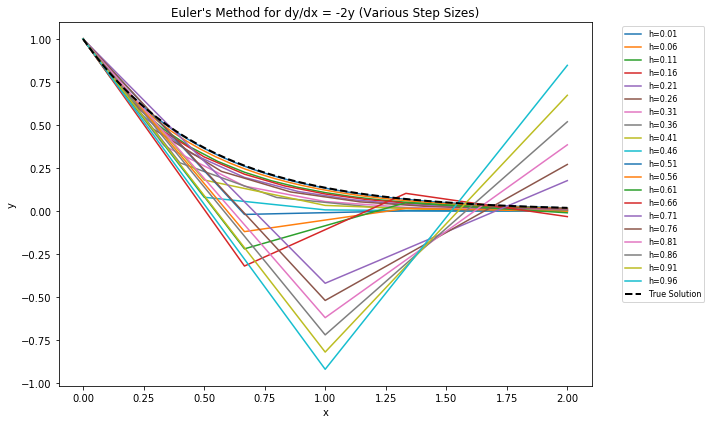

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def true_solution(x):
    return np.exp(-2 * x)

def f(x, y):
    return -2 * y

step_sizes = np.arange(0.01, 1.01, 0.05)

x_start, x_end = 0, 2

all_errors = []
baseline_y = None

plt.figure(figsize=(10, 6))

for idx, h in enumerate(step_sizes):

    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    true_y = true_solution(x_values)

    error = np.abs(true_y - y_values)
    total_error = np.sum(error)

    if idx == 0:
        baseline_y = y_values.copy()

    baseline_interp = np.interp(x_values,
                               np.linspace(x_start, x_end, len(baseline_y)),
                               baseline_y)

    error_vs_baseline = np.abs(baseline_interp - y_values)

    print(f"h = {h:.2f}")
    print(f"  Total error vs true solution: {total_error:.6f}")
    print(f"  Avg error vs first run: {np.mean(error_vs_baseline):.6f}")

    plt.plot(x_values, y_values, label=f"h={h:.2f}")

x_fine = np.linspace(x_start, x_end, 200)
plt.plot(x_fine, true_solution(x_fine), 'k--', linewidth=2, label="True Solution")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for dy/dx = -2y (Various Step Sizes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()